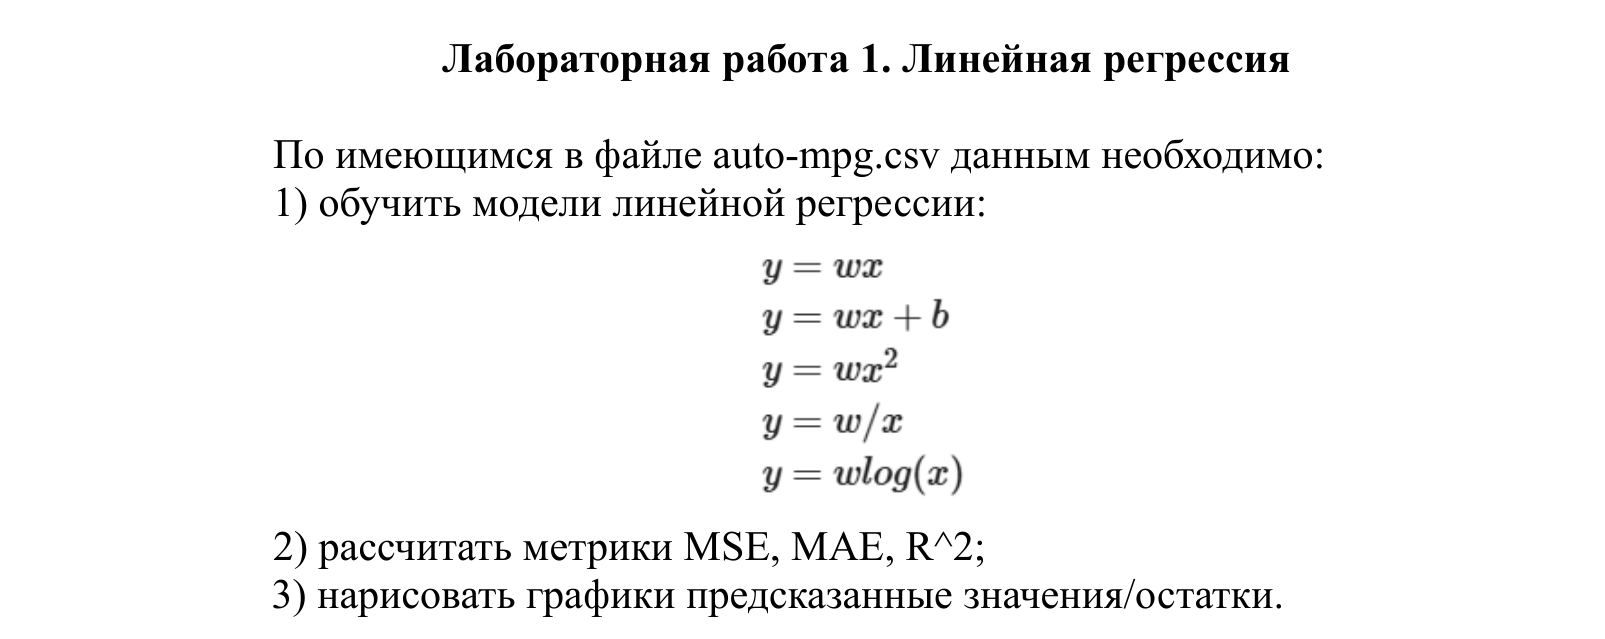

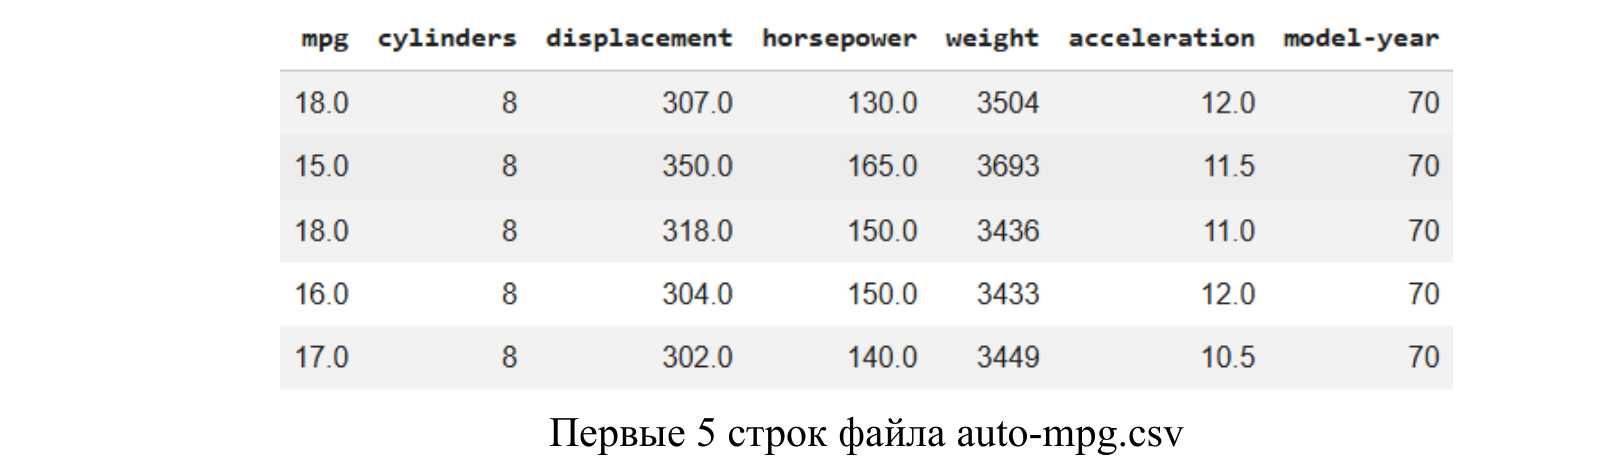

Мой Вариант: 22 mod 5 = 2

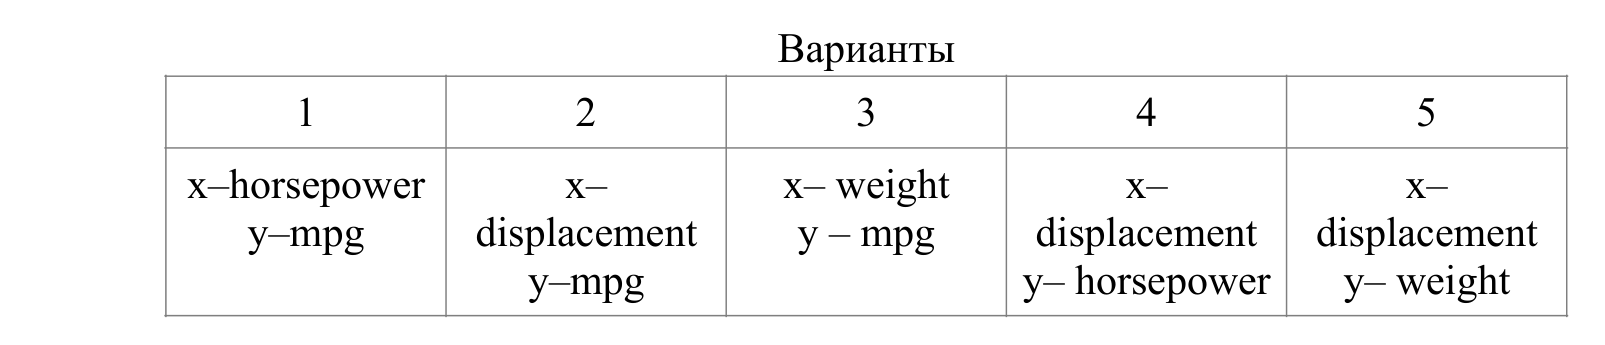

x – displacement, y – mpg

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('auto-mpg.csv')
df.head()

,Unnamed: 0,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,0,18.0,8,307.0,130.0,3504,12.0,70
1,1,15.0,8,350.0,165.0,3693,11.5,70
2,2,18.0,8,318.0,150.0,3436,11.0,70
3,3,16.0,8,304.0,150.0,3433,12.0,70
4,4,17.0,8,302.0,140.0,3449,10.5,70


In [3]:
# мой вариант
x = df['displacement'].values
y = df['mpg'].values

n = len(x)
print(f"количество наблюдений: {n}")

количество наблюдений: 396


# Пункт 1

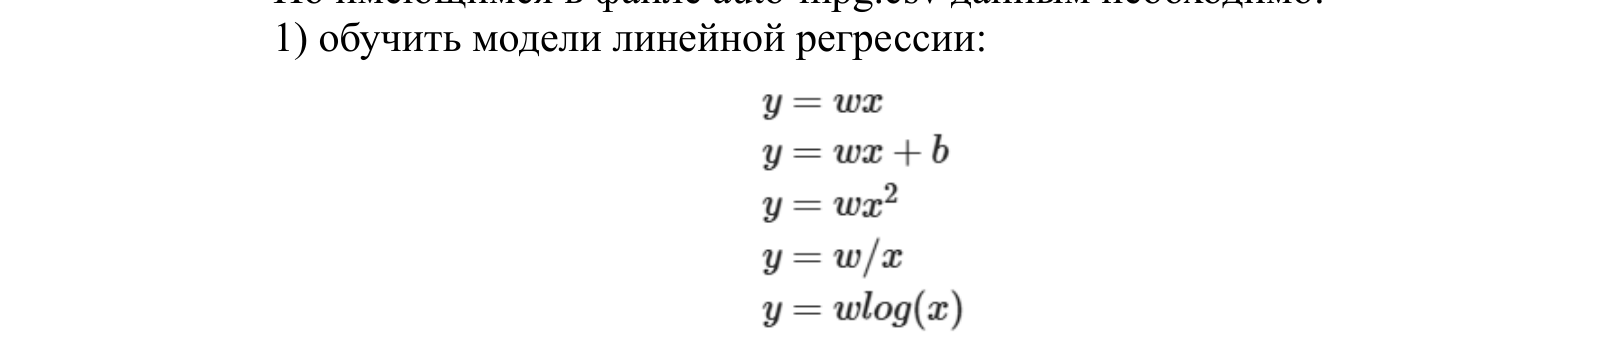

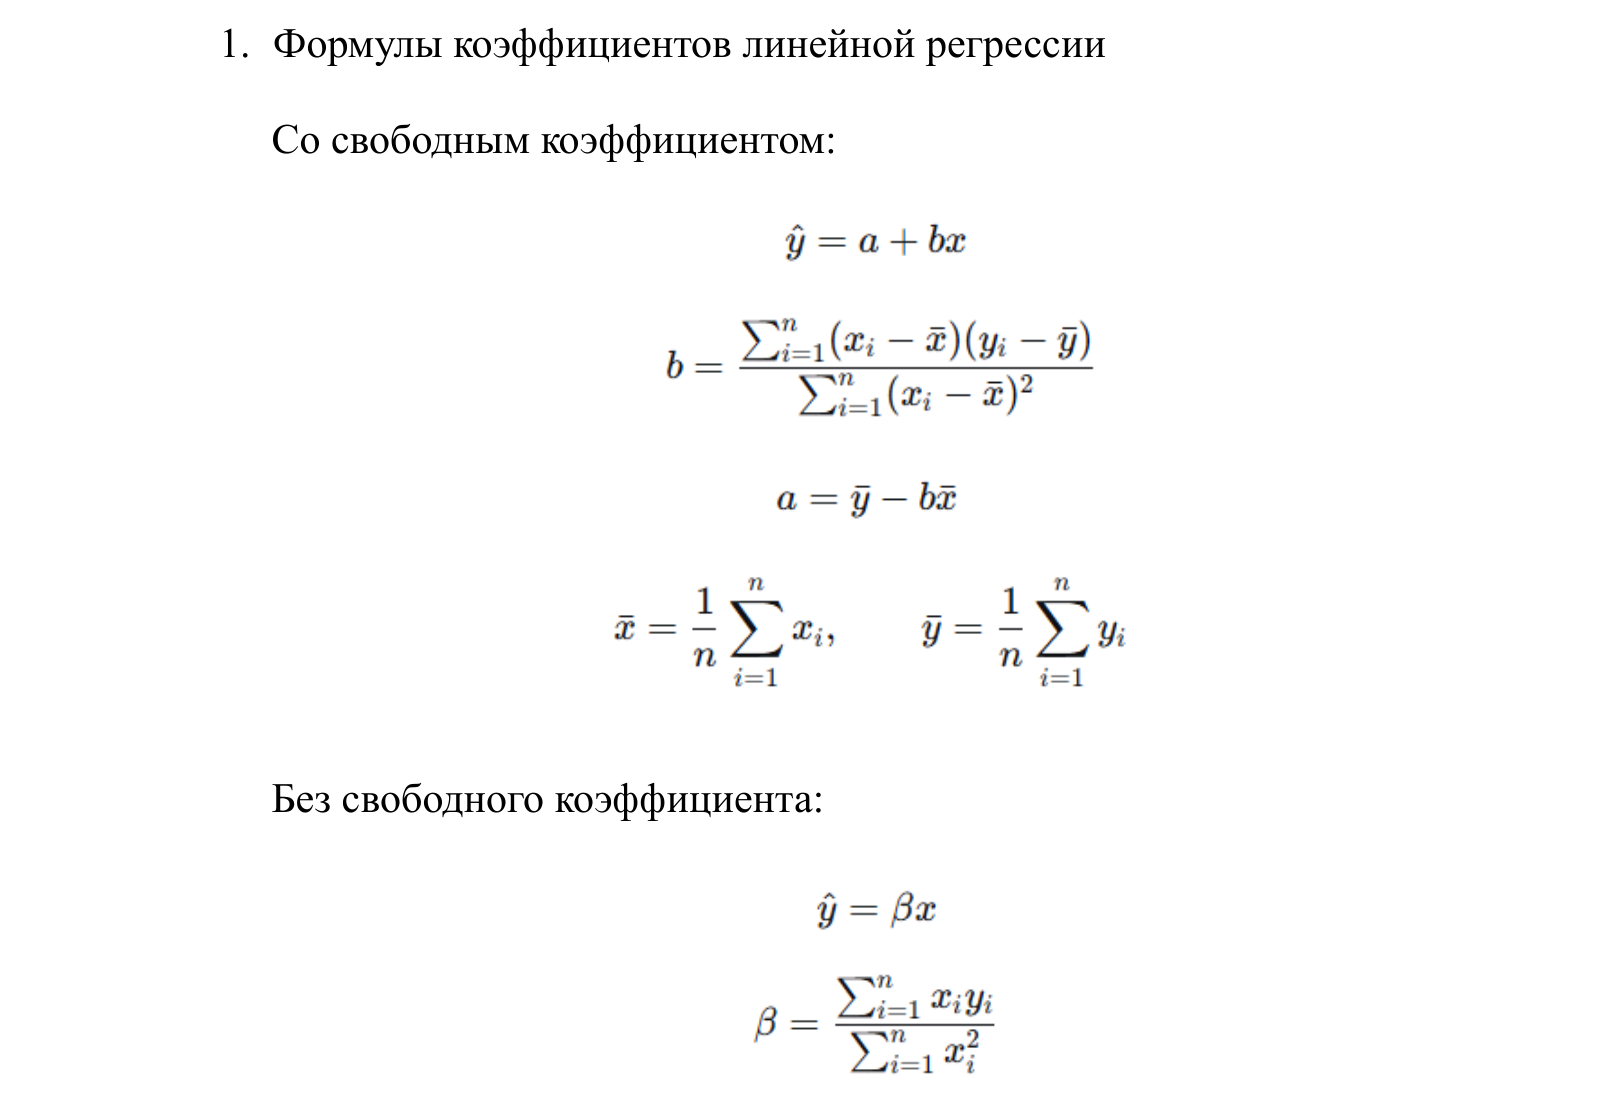

In [4]:
# коэффициенты для y = a + bx
def fit_with_intercept(x, y):
    x_mean, y_mean = x.mean(), y.mean()
    b = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    a = y_mean - b * x_mean
    return a, b

# коэффициент для y = w*z, то есть без свободного члена
def fit_no_intercept(z, y):
    return np.sum(z * y) / np.sum(z ** 2)

In [5]:
# y = wx
w1 = fit_no_intercept(x, y)

# y = wx + b
a2, b2 = fit_with_intercept(x, y)

# y = wx^2, тут в качестве x подставляем x^2
w3 = fit_no_intercept(x ** 2, y)

# y = w/x, тут в качестве x подставляем 1/x
w4 = fit_no_intercept(1 / x, y)

# y = w*log(x), тут в качестве x подставляем log(x)
w5 = fit_no_intercept(np.log(x), y)

print(f"y = wx      : w = {w1:.5f}")
print(f"y = wx + b  : w = {b2:.5f}, b = {a2:.5f}")
print(f"y = wx^2    : w = {w3:.5f}")
print(f"y = w/x     : w = {w4:.5f}")
print(f"y = w*log(x): w = {w5:.5f}")

y = wx      : w = 0.08056
y = wx + b  : w = -0.06037, b = 35.20862
y = wx^2    : w = 0.00018
y = w/x     : w = 3175.76922
y = w*log(x): w = 4.41091


In [6]:
y_pred1 = w1 * x
y_pred2 = a2 + b2 * x
y_pred3 = w3 * x ** 2
y_pred4 = w4 / x
y_pred5 = w5 * np.log(x)

preds = {
    "y = wx": y_pred1,
    "y = wx + b": y_pred2,
    "y = wx^2": y_pred3,
    "y = w/x": y_pred4,
    "y = w*log(x)": y_pred5,
}

# Пункт 2

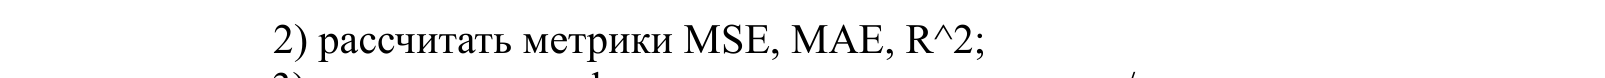

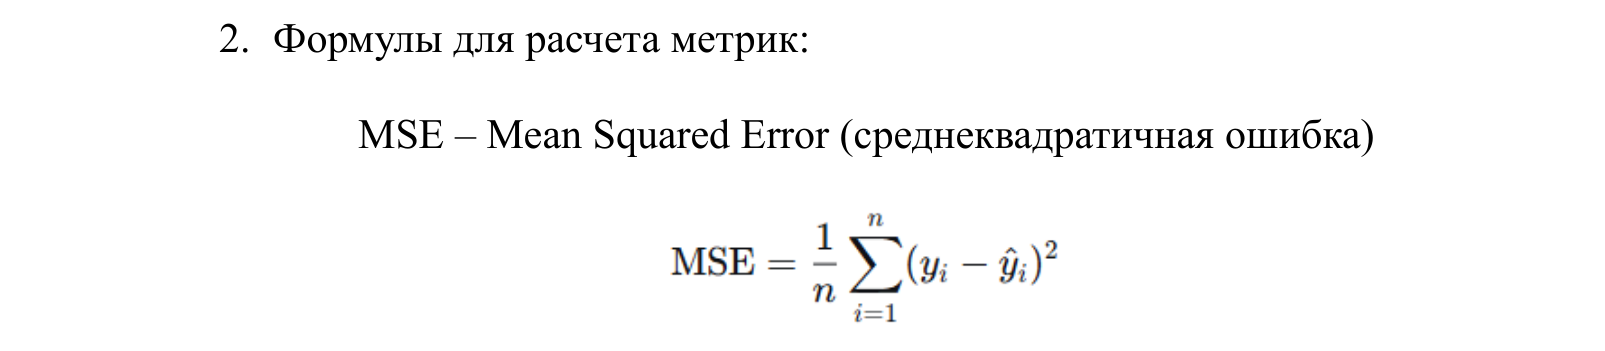

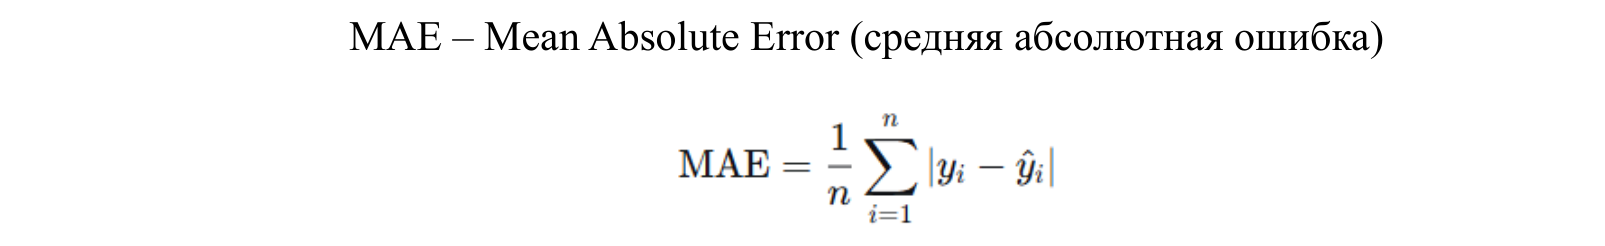

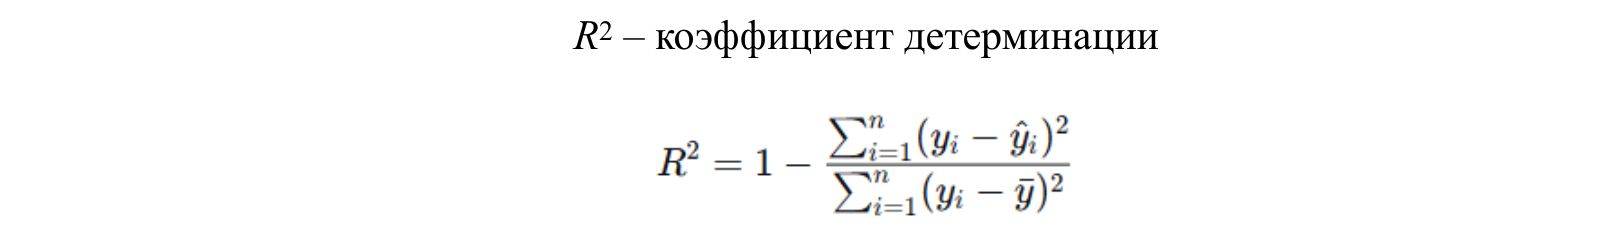

In [7]:
def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def mae(y, y_pred):
    return np.mean(np.abs(y - y_pred))

def r2(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

In [8]:
metrics = pd.DataFrame({
    name: [mse(y, p), mae(y, p), r2(y, p)]
    for name, p in preds.items()
}, index=["MSE", "MAE", "R2"]).T

metrics

,MSE,MAE,R2
y = wx,300.284907,14.983548,-3.904826
y = wx + b,21.577217,3.529575,0.647560
y = wx^2,462.211759,18.660431,-6.549725
y = w/x,40.796755,5.298090,0.333630
y = w*log(x),97.944722,8.433087,-0.599820


# Пункт 3

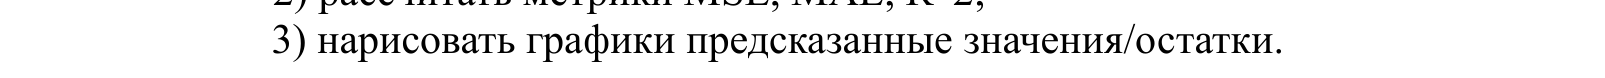

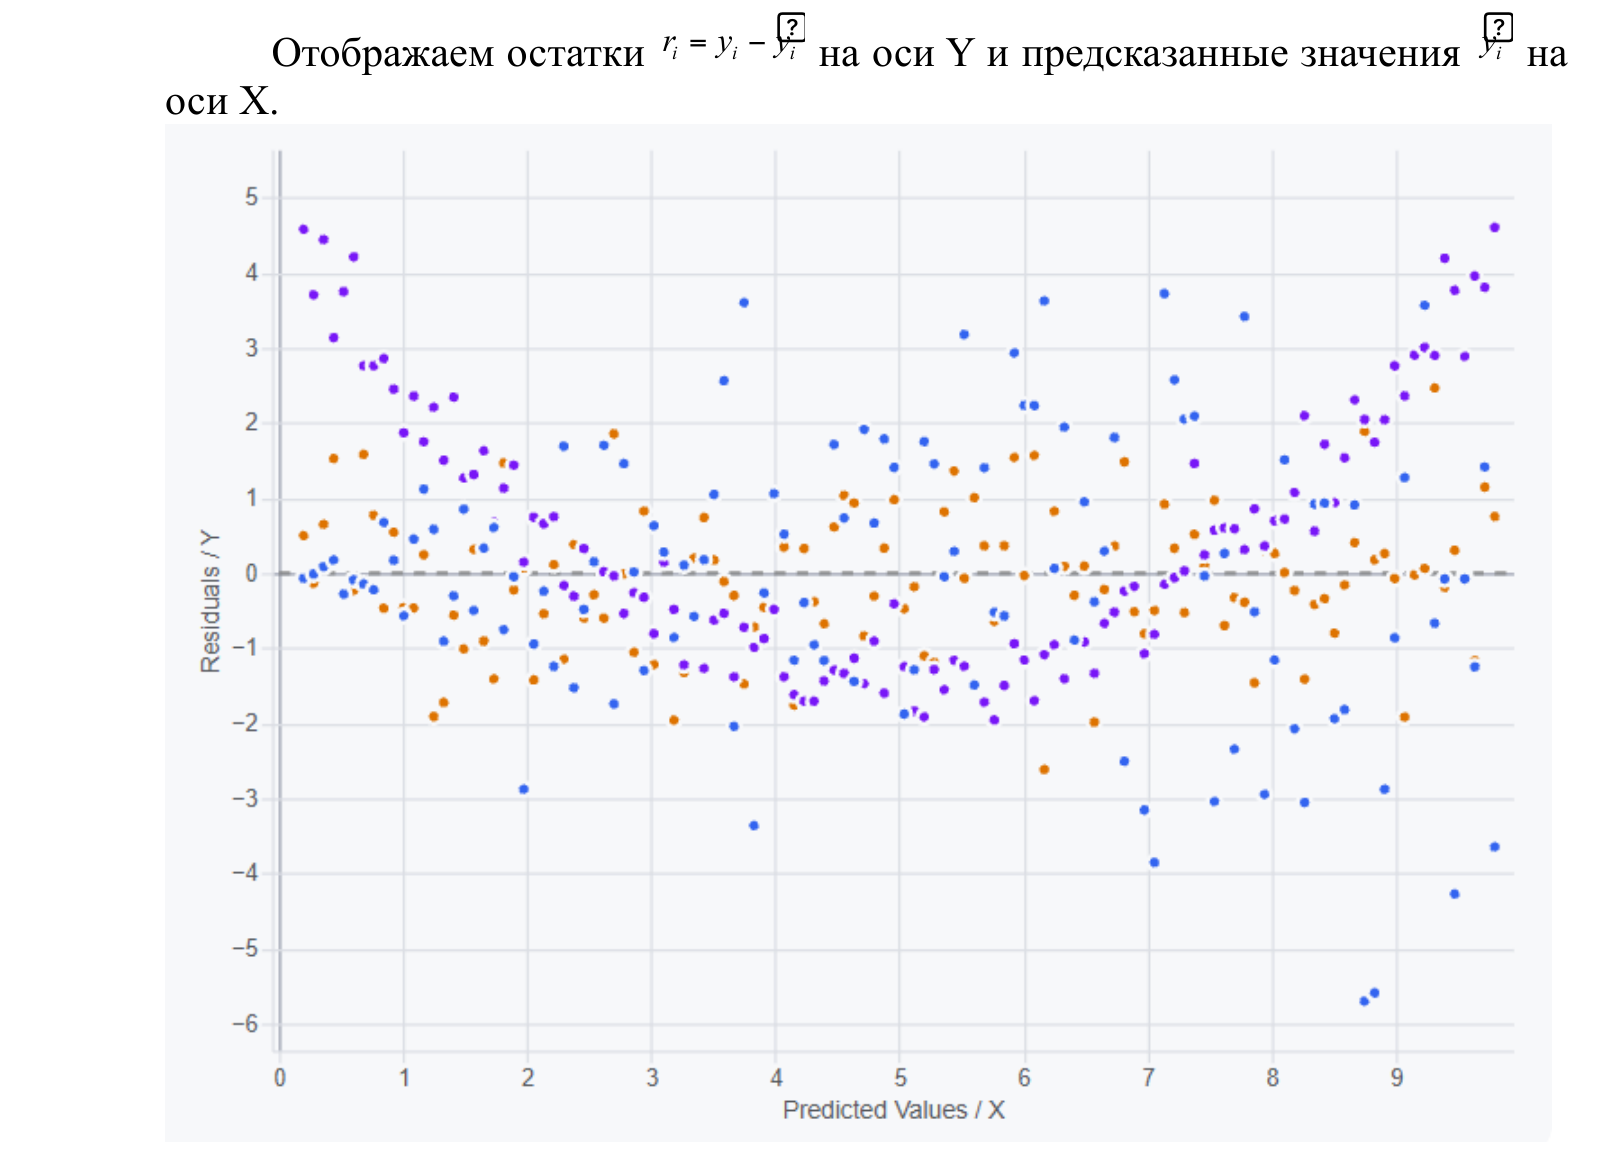

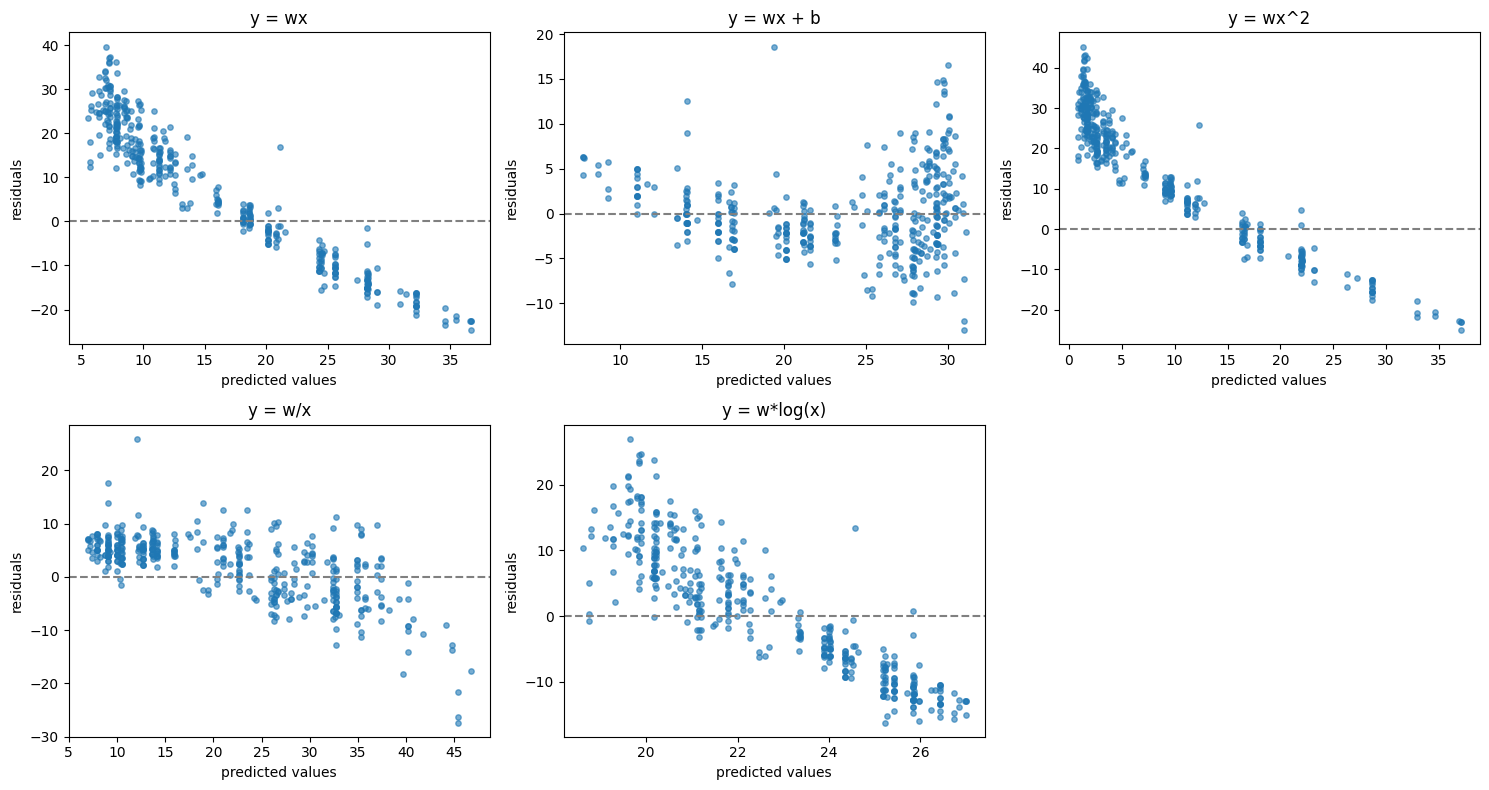

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, preds.items()):
    residuals = y - y_pred
    ax.scatter(y_pred, residuals, alpha=0.6, s=15)
    ax.axhline(0, color='gray', linestyle='--')
    ax.set_title(name)
    ax.set_xlabel('predicted values')
    ax.set_ylabel('residuals')

axes[-1].axis('off')  # лишний subplot, моделей всего 5

plt.tight_layout()
plt.show()

# Выводы

- лучшая модель — y = wx + b: R2 = 0.65, MSE и MAE ниже, чем у всех остальных
- на втором месте y = w/x: R2 = 0.33
- у y = wx, y = wx^2, y = w*log(x) отрицательный R2 — хуже, чем просто предсказывать среднее значение
- на графике остатков только у y = wx + b точки лежат более-менее ровно вокруг нуля
- у остальных моделей остатки явно убывают с ростом предсказанного значения, то есть ошибка не случайная, а системная
- причина в том, что у этих моделей нет свободного члена, поэтому линия вынуждена проходить через ноль и плохо ложится на данные